# Task 7 — JPEG compression robustness

Analyse how JPEG compression at different quality levels affects the face recognition system.

### Quality levels tested
| Quality | Compression | Typical use |
|---|---|---|
| 95 | very light | high-quality web images |
| 70 | moderate | typical web JPEG |
| 30 | heavy | low-bandwidth / thumbnails |
| 10 | severe | heavily degraded |
| 5  | extreme | near-maximum compression |

The spec requires **at least 3** quality levels — we test 5 for a fuller picture.  
Source: `data/enrolled_test/` — held-out images of enrolled users.

## 1. Setup

In [1]:
import sys
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding
from src.database import EmbeddingDB
from src.degradation import apply_jpeg
from src.metrics import compute_far_frr, compute_roc, eer
from src.utils import list_images, psnr as compute_psnr

warnings.filterwarnings('ignore')

SEED           = 44
DEFAULT_THRESH = 0.4
TEST_DIR       = Path('../data/enrolled_test')

# Quality levels — spec requires >= 3, we test 5
JPEG_QUALITIES = [95, 70, 30, 10, 5]

random.seed(SEED)
np.random.seed(SEED)
rng = random.Random(SEED)

print('Loading model...')
app = get_insightface_model('buffalo_l', ctx_id=0)
db  = EmbeddingDB.from_file()

enrolled_users = set(db.get_all_users())
user_list      = sorted(enrolled_users)
print(f'Enrolled users : {len(enrolled_users)}')

Loading model...
Enrolled users : 105


## 2. Load enrolled test images

In [2]:
all_probes = []   # (user_id, img_bgr)
for user_dir in sorted(d for d in TEST_DIR.iterdir()
                       if d.is_dir() and d.name in enrolled_users):
    for img_path in list_images(user_dir):
        img = cv2.imread(str(img_path))
        if img is not None:
            all_probes.append((user_dir.name, img))

print(f'Total probes : {len(all_probes)}')

Total probes : 2397


## 3. Visualise JPEG quality levels

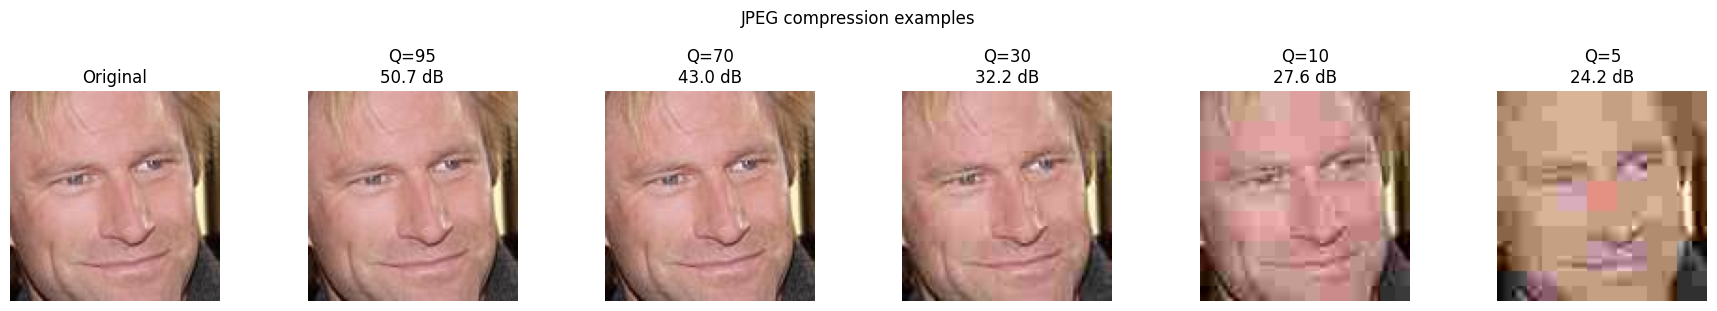

In [3]:
sample_img = all_probes[0][1]

fig, axes = plt.subplots(1, len(JPEG_QUALITIES) + 1, figsize=(3 * (len(JPEG_QUALITIES) + 1), 3))
axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

for ax, q in zip(axes[1:], JPEG_QUALITIES):
    compressed = apply_jpeg(sample_img, q)
    actual_psnr = compute_psnr(sample_img, compressed)
    ax.imshow(cv2.cvtColor(compressed, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Q={q}\n{actual_psnr:.1f} dB')
    ax.axis('off')

plt.suptitle('JPEG compression examples', y=1.02)
plt.tight_layout()

out_dir = Path('../results/task7')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'jpeg_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Score computation per quality level

In [4]:
quality_results = {}

for q in JPEG_QUALITIES:
    scores_gen  = []
    scores_imp  = []
    psnr_vals   = []

    for user_id, img in all_probes:
        compressed = apply_jpeg(img, q)
        psnr_vals.append(compute_psnr(img, compressed))

        emb = get_embedding(app, compressed, fallback=True)
        if emb is None:
            continue

        # Genuine
        refs = db.get_user_embeddings(user_id)
        if refs:
            scores_gen.append(max(float(np.dot(emb, r)) for r in refs))

        # Impostor
        candidates = [u for u in user_list if u != user_id]
        if candidates:
            imp_refs = db.get_user_embeddings(rng.choice(candidates))
            if imp_refs:
                scores_imp.append(max(float(np.dot(emb, r)) for r in imp_refs))

    scores = np.concatenate([scores_gen, scores_imp])
    labels = np.concatenate([np.ones(len(scores_gen)), np.zeros(len(scores_imp))])

    far, frr, acc       = compute_far_frr(scores, labels, DEFAULT_THRESH)
    fpr, tpr, thr       = compute_roc(scores, labels)
    eer_val, _          = eer(fpr, tpr, thr)
    auc_val             = auc(fpr, tpr)

    quality_results[q] = {
        'scores_gen': np.array(scores_gen),
        'scores_imp': np.array(scores_imp),
        'scores': scores, 'labels': labels,
        'FAR': far, 'FRR': frr, 'Accuracy': acc,
        'EER': eer_val, 'AUC': auc_val,
        'mean_psnr': float(np.mean(psnr_vals)),
        'n_genuine': len(scores_gen), 'n_impostor': len(scores_imp),
        'fpr': fpr, 'tpr': tpr,
    }

    print(f'  Q={q:2d}  PSNR={np.mean(psnr_vals):5.1f} dB  '
          f'n={len(scores_gen)+len(scores_imp)}  '
          f'FAR={far*100:5.2f}%  FRR={frr*100:5.2f}%  '
          f'Acc={acc*100:5.2f}%  EER={eer_val*100:5.2f}%')

  Q=95  PSNR= 50.2 dB  n=4794  FAR= 0.00%  FRR= 2.04%  Acc=98.98%  EER= 0.83%
  Q=70  PSNR= 43.0 dB  n=4794  FAR= 0.00%  FRR= 2.04%  Acc=98.98%  EER= 0.71%
  Q=30  PSNR= 32.6 dB  n=4794  FAR= 0.00%  FRR= 2.25%  Acc=98.87%  EER= 0.77%
  Q=10  PSNR= 28.0 dB  n=4794  FAR= 0.00%  FRR= 3.92%  Acc=98.04%  EER= 0.90%
  Q= 5  PSNR= 24.7 dB  n=4794  FAR= 0.00%  FRR=15.60%  Acc=92.20%  EER= 1.38%


## 5. Score distributions per quality level

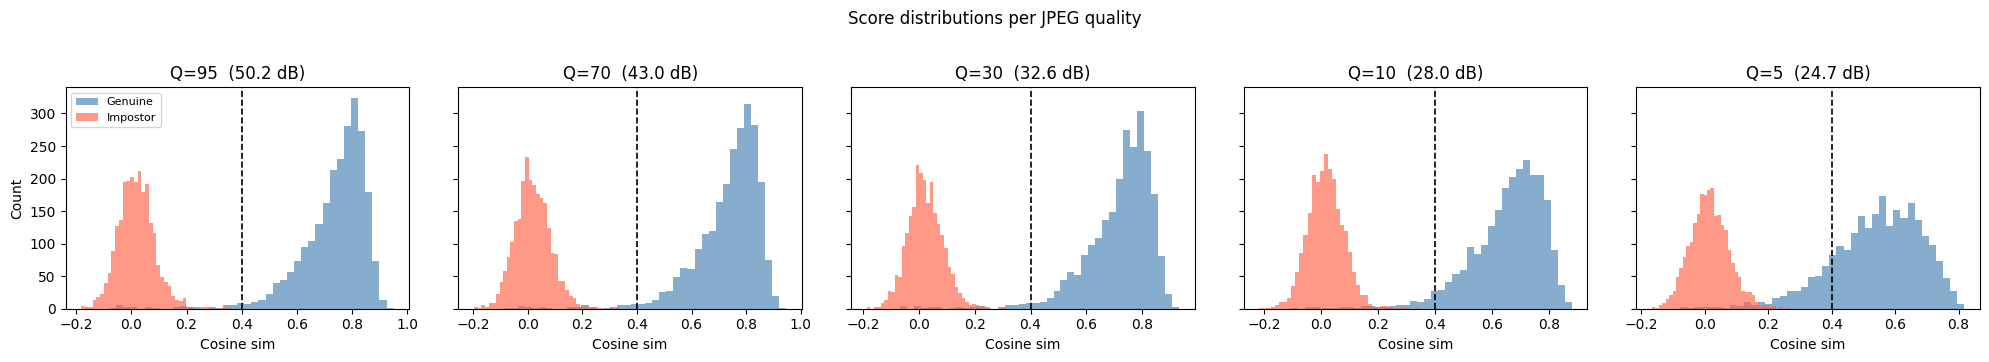

In [5]:
fig, axes = plt.subplots(1, len(JPEG_QUALITIES), figsize=(4 * len(JPEG_QUALITIES), 3.5), sharey=True)

for ax, q in zip(axes, JPEG_QUALITIES):
    res = quality_results[q]
    ax.hist(res['scores_gen'], bins=40, alpha=0.65, color='steelblue', label='Genuine')
    ax.hist(res['scores_imp'], bins=40, alpha=0.65, color='tomato',    label='Impostor')
    ax.axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.2)
    ax.set_title(f'Q={q}  ({res["mean_psnr"]:.1f} dB)')
    ax.set_xlabel('Cosine sim')

axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
plt.suptitle('Score distributions per JPEG quality', y=1.02)
plt.tight_layout()
plt.savefig(out_dir / 'score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Metrics vs JPEG quality

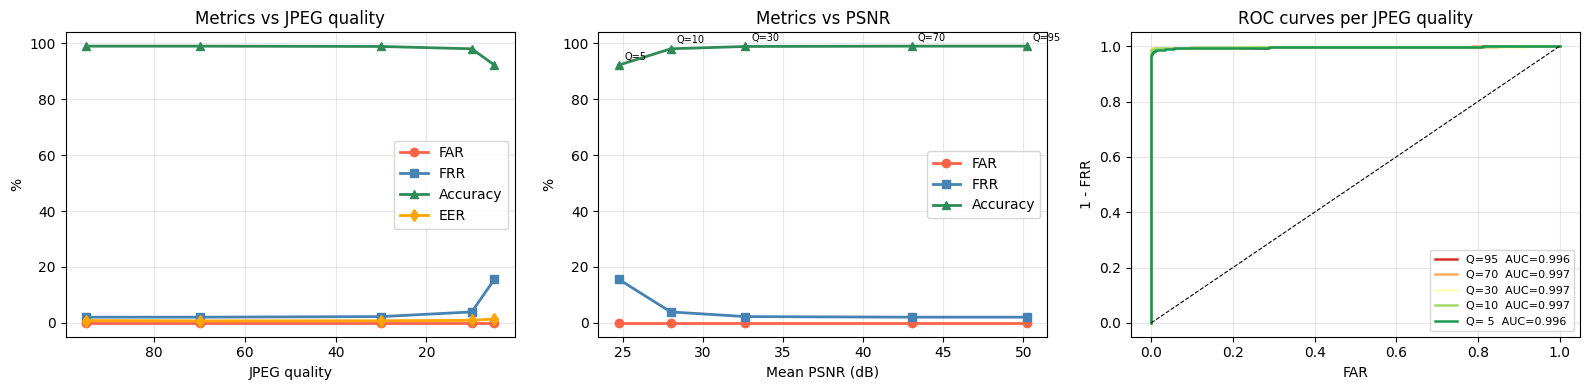

In [6]:
qualities  = JPEG_QUALITIES
mean_psnrs = [quality_results[q]['mean_psnr'] for q in qualities]
fars       = [quality_results[q]['FAR']       for q in qualities]
frrs       = [quality_results[q]['FRR']       for q in qualities]
accs       = [quality_results[q]['Accuracy']  for q in qualities]
eers       = [quality_results[q]['EER']       for q in qualities]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Metrics vs quality ────────────────────────────────────────────────────────
axes[0].plot(qualities, [f*100 for f in fars],  'o-', color='tomato',    lw=2, label='FAR')
axes[0].plot(qualities, [f*100 for f in frrs],  's-', color='steelblue', lw=2, label='FRR')
axes[0].plot(qualities, [a*100 for a in accs],  '^-', color='seagreen',  lw=2, label='Accuracy')
axes[0].plot(qualities, [e*100 for e in eers],  'd-', color='orange',    lw=2, label='EER')
axes[0].set_xlabel('JPEG quality')
axes[0].set_ylabel('%')
axes[0].set_title('Metrics vs JPEG quality')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()   # left = low quality (heavy compression)

# ── Metrics vs PSNR ───────────────────────────────────────────────────────────
axes[1].plot(mean_psnrs, [f*100 for f in fars],  'o-', color='tomato',    lw=2, label='FAR')
axes[1].plot(mean_psnrs, [f*100 for f in frrs],  's-', color='steelblue', lw=2, label='FRR')
axes[1].plot(mean_psnrs, [a*100 for a in accs],  '^-', color='seagreen',  lw=2, label='Accuracy')
for q, psnr_v in zip(qualities, mean_psnrs):
    axes[1].annotate(f'Q={q}', (psnr_v, quality_results[q]['Accuracy']*100),
                     textcoords='offset points', xytext=(4, 4), fontsize=7)
axes[1].set_xlabel('Mean PSNR (dB)')
axes[1].set_ylabel('%')
axes[1].set_title('Metrics vs PSNR')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── ROC overlay ───────────────────────────────────────────────────────────────
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(qualities)))
for q, color in zip(qualities, colors):
    res     = quality_results[q]
    auc_val = res['AUC']
    axes[2].plot(res['fpr'], res['tpr'], color=color, lw=1.8,
                 label=f'Q={q:2d}  AUC={auc_val:.3f}')
axes[2].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[2].set_xlabel('FAR')
axes[2].set_ylabel('1 - FRR')
axes[2].set_title('ROC curves per JPEG quality')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / 'metrics_vs_quality.png', dpi=150)
plt.show()

## 7. Summary table

In [7]:
rows = []
for q in qualities:
    res = quality_results[q]
    rows.append({
        'JPEG quality':  q,
        'Mean PSNR (dB)': round(res['mean_psnr'], 1),
        'Genuine':        res['n_genuine'],
        'Impostor':       res['n_impostor'],
        'FAR (%)':        round(res['FAR']      * 100, 2),
        'FRR (%)':        round(res['FRR']      * 100, 2),
        'Accuracy (%)':   round(res['Accuracy'] * 100, 2),
        'EER (%)':        round(res['EER']      * 100, 2),
        'AUC':            round(res['AUC'],            4),
    })

df = pd.DataFrame(rows)
display(
    df.style
      .highlight_max(subset=['FAR (%)'],      color='#f4cccc')
      .highlight_max(subset=['FRR (%)'],      color='#fce5cd')
      .highlight_max(subset=['Accuracy (%)'], color='#d9ead3')
      .highlight_min(subset=['EER (%)'],      color='#d9ead3')
      .highlight_min(subset=['AUC'],          color='#f4cccc')
)

df.to_csv(out_dir / 'jpeg_results.csv', index=False)
print(f'Saved → {out_dir / "jpeg_results.csv"}')

,JPEG quality,Mean PSNR (dB),Genuine,Impostor,FAR (%),FRR (%),Accuracy (%),EER (%),AUC
0,95,50.200000,2397,2397,0.000000,2.040000,98.980000,0.830000,0.996300
1,70,43.000000,2397,2397,0.000000,2.040000,98.980000,0.710000,0.996600
2,30,32.600000,2397,2397,0.000000,2.250000,98.870000,0.770000,0.996600
3,10,28.000000,2397,2397,0.000000,3.920000,98.040000,0.900000,0.997200
4,5,24.700000,2397,2397,0.000000,15.600000,92.200000,1.380000,0.996000


Saved → ..\results\task7\jpeg_results.csv


## 8. Summary

In [8]:
print('=' * 68)
print('TASK 7 — JPEG COMPRESSION ROBUSTNESS')
print(f'Threshold : {DEFAULT_THRESH}   Quality levels tested : {len(JPEG_QUALITIES)}')
print('=' * 68)
print(f'{"Quality":>8} {"PSNR (dB)":>10} {"n":>6} {"FAR":>8} {"FRR":>8} {"Acc":>8} {"EER":>8} {"AUC":>7}')
print('-' * 68)
for q in qualities:
    res = quality_results[q]
    n = res['n_genuine'] + res['n_impostor']
    print(f'{q:>8}  {res["mean_psnr"]:>9.1f}  {n:>6}  '
          f'{res["FAR"]*100:>7.2f}%  {res["FRR"]*100:>7.2f}%  '
          f'{res["Accuracy"]*100:>7.2f}%  {res["EER"]*100:>7.2f}%  {res["AUC"]:>6.4f}')
print('=' * 68)

# Find quality threshold where accuracy drops significantly
accs_vals = [(q, quality_results[q]['Accuracy']) for q in qualities]
max_acc   = max(a for _, a in accs_vals)
degraded  = [(q, a) for q, a in accs_vals if a < max_acc * 0.95]
if degraded:
    q_break = max(q for q, _ in degraded)
    print(f'\nAccuracy drops >5% below peak at quality ≤ {q_break}')
else:
    print('\nAccuracy remains stable across all tested quality levels.')

TASK 7 — JPEG COMPRESSION ROBUSTNESS
Threshold : 0.4   Quality levels tested : 5
 Quality  PSNR (dB)      n      FAR      FRR      Acc      EER     AUC
--------------------------------------------------------------------
      95       50.2    4794     0.00%     2.04%    98.98%     0.83%  0.9963
      70       43.0    4794     0.00%     2.04%    98.98%     0.71%  0.9966
      30       32.6    4794     0.00%     2.25%    98.87%     0.77%  0.9966
      10       28.0    4794     0.00%     3.92%    98.04%     0.90%  0.9972
       5       24.7    4794     0.00%    15.60%    92.20%     1.38%  0.9960

Accuracy drops >5% below peak at quality ≤ 5
